# kx demo

Every `kx` feature on the dummy CSVs in `data/`. Spec grammar: `kind-theme-flag-...` (run `kx.grammar()`).

## Setup
On Kaggle replace `'..'` with `'/kaggle/input/<slug>'`.

In [1]:
import sys; sys.path.append('..')
import kx; kx.use('dark')

In [2]:
kx.grammar()
print('data :', kx.datasets())

kind : ['bar', 'hist', 'line', 'scatter']
theme: ['dark', 'light', 'paper']
flags: ['grid', 'leg', 'logx', 'logy', 'tight']
data : ['cloud', 'dists', 'monthly', 'waves']


In [3]:
waves, cloud, monthly, dists = (kx.load(n) for n in ('waves', 'cloud', 'monthly', 'dists'))
monthly.head(3)

,month,y2025,y2026
0,Jan,104,104
1,Feb,115,142
2,Mar,145,148


## One kind per dataset

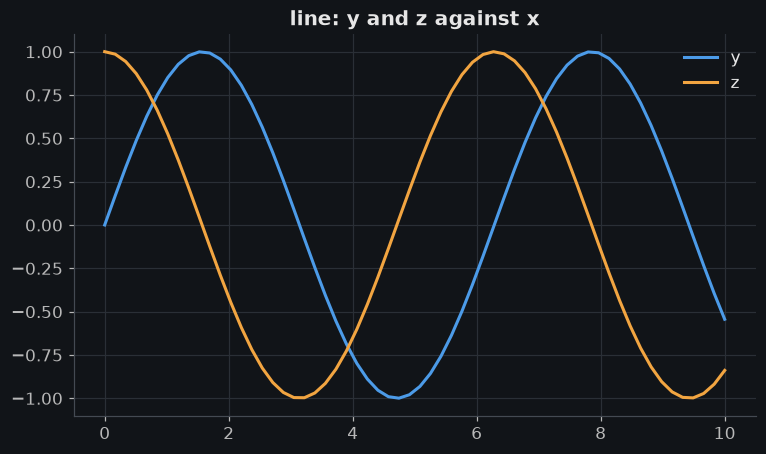

In [4]:
kx.plot(waves.x, waves.y, waves.z, 'line-grid-leg', title='line: y and z against x');

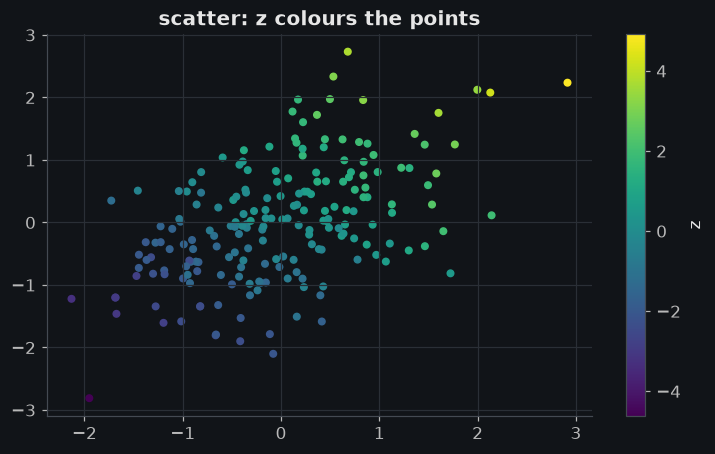

In [5]:
kx.plot(cloud.x, cloud.y, cloud.z, 'scatter-grid', title='scatter: z colours the points');

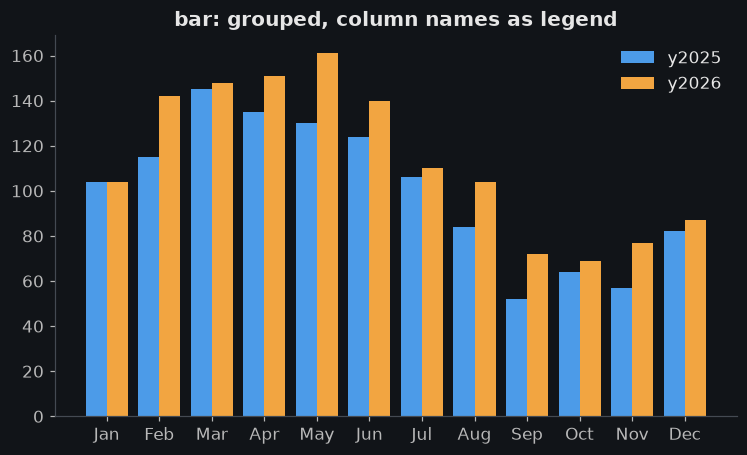

In [6]:
kx.plot(monthly.month, monthly.y2025, monthly.y2026, 'bar-leg', title='bar: grouped, column names as legend');

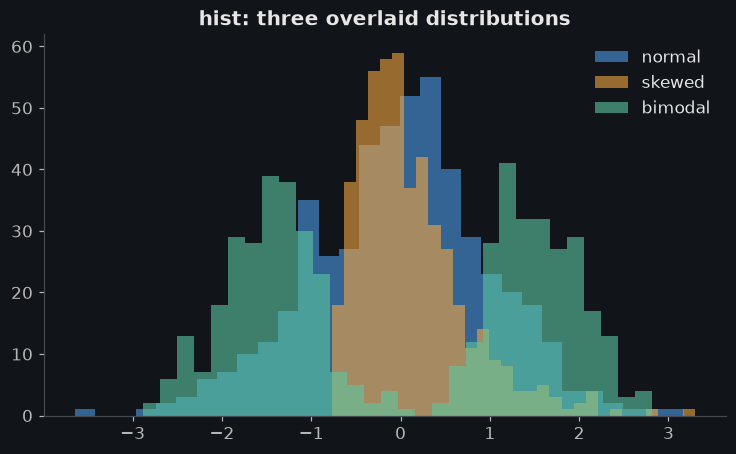

In [7]:
kx.plot(dists.normal, dists.skewed, dists.bimodal, 'hist-leg', title='hist: three overlaid distributions');

## Shortcuts and flags
Spec can be the 3rd argument when there is no `z`; tokens go in any order.

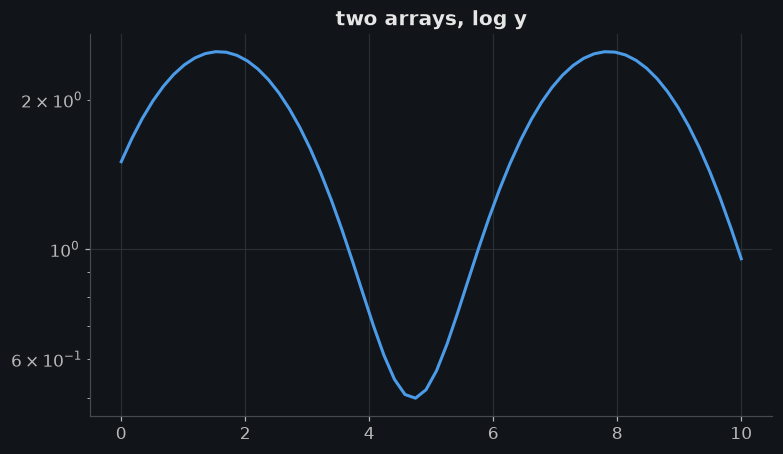

In [8]:
kx.plot(waves.x, waves.y + 1.5, 'logy-line-grid', title='two arrays, log y');

## Per-plot theme
A theme in the spec styles only that plot; the notebook default (`dark`) is untouched.

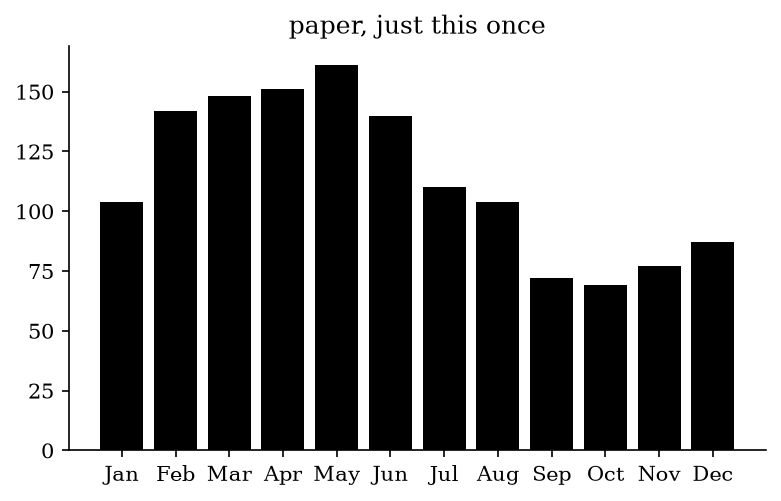

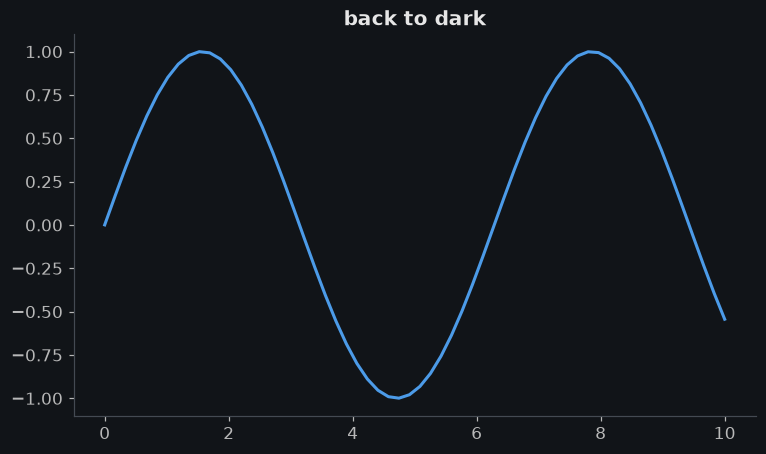

In [9]:
kx.plot(monthly.month, monthly.y2026, 'bar-paper', title='paper, just this once');
kx.plot(waves.x, waves.y, 'line', title='back to dark');

## Overrides
`kx.use` takes a palette and rcParams (`__` for dots).

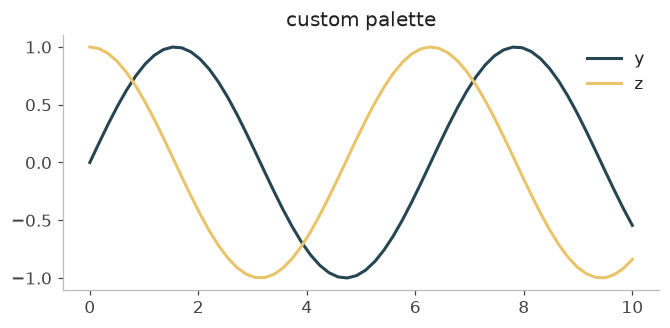

In [10]:
kx.use('light', palette=['#264653', '#e9c46a'], figure__figsize=(7, 3))
kx.plot(waves.x, waves.y, waves.z, 'line-leg', title='custom palette');
kx.use('dark')

## All themes side by side
Pass `ax=` to draw into your own grid.

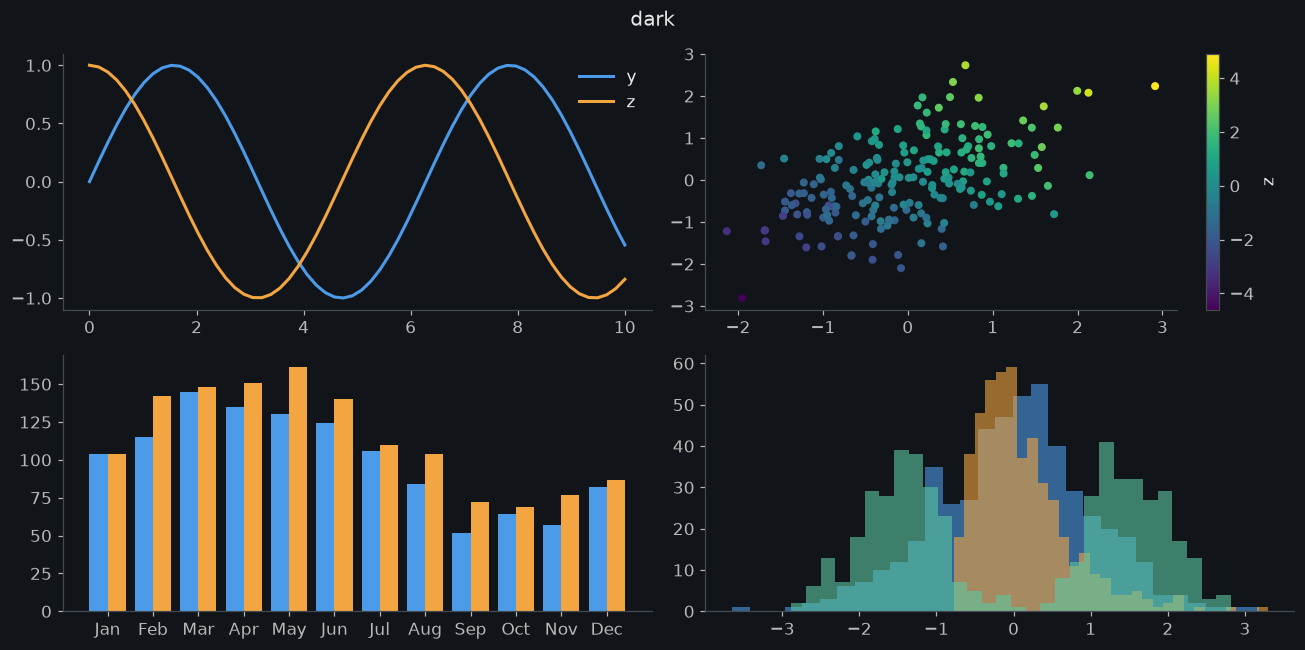

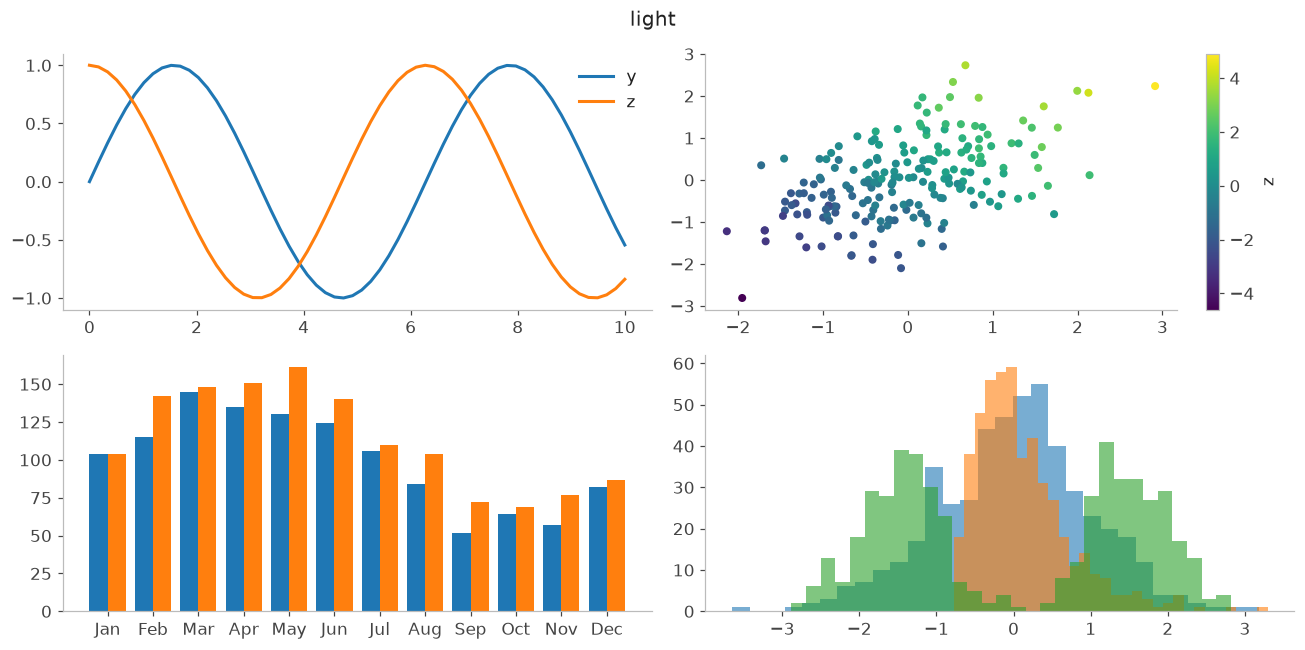

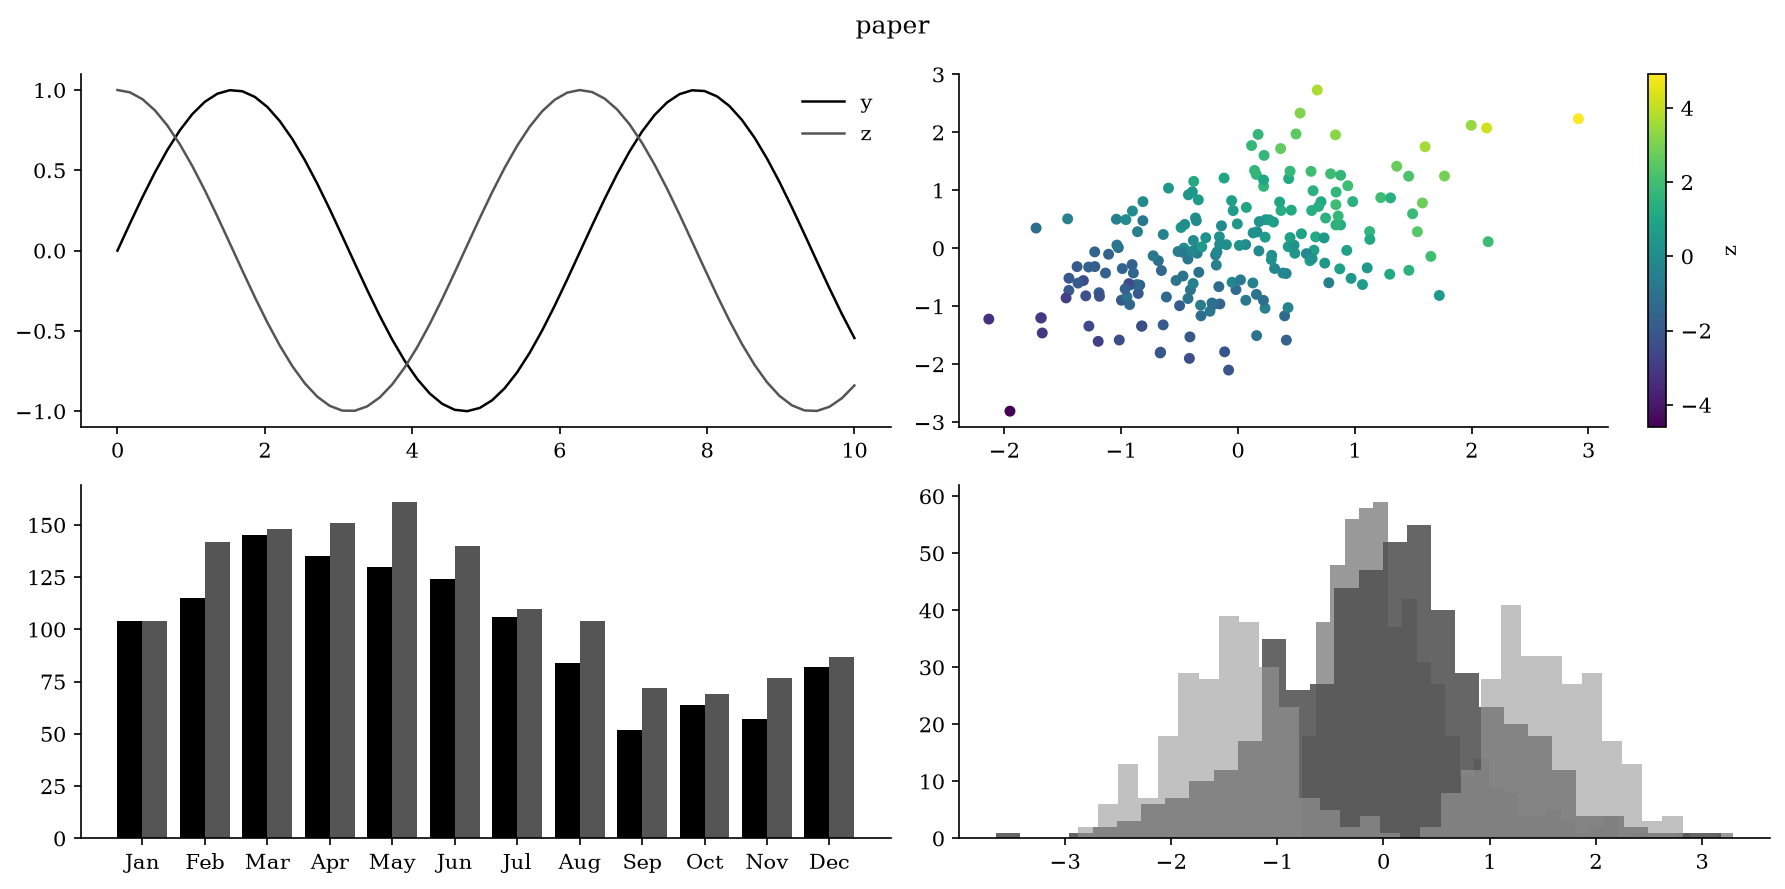

In [11]:
import matplotlib.pyplot as plt

for theme in kx.styles():
    kx.use(theme)
    fig, axs = plt.subplots(2, 2, figsize=(12, 6))
    axs = iter(axs.flat)
    kx.plot(waves.x, waves.y, waves.z, 'line-leg', ax=next(axs))
    kx.plot(cloud.x, cloud.y, cloud.z, 'scatter', ax=next(axs))
    kx.plot(monthly.month, monthly.y2025, monthly.y2026, 'bar', ax=next(axs))
    kx.plot(dists.normal, dists.skewed, dists.bimodal, 'hist', ax=next(axs))
    fig.suptitle(theme); fig.tight_layout()
kx.use('dark')

## Strict errors
Unknown or conflicting tokens fail loudly instead of guessing.

In [12]:
for spec in ('line-nope', 'line-scatter', 'dark-light'):
    try:
        kx.plot(waves.x, waves.y, spec=spec)
    except ValueError as e:
        print(e)

unknown tokens: ['nope']. Run kx.grammar() to see valid ones.
spec 'line-scatter' has more than one kind: ['line', 'scatter']
spec 'dark-light' has more than one theme: ['dark', 'light']


## Transparency
What a theme does, in plain text (`kx.source()` prints the whole module).

In [13]:
kx.show('dark')

figure.facecolor: 111418
axes.facecolor:   111418
savefig.facecolor: 111418
text.color:       E6E6E6
axes.labelcolor:  E6E6E6
xtick.color:      B8B8B8
ytick.color:      B8B8B8
axes.edgecolor:   444A52
grid.color:       2A2F36
grid.linestyle:   -
axes.grid:        False
axes.spines.top:  False
axes.spines.right: False
axes.prop_cycle:  cycler('color', ['4C9BE8', 'F2A541', '5CC8A1', 'E26A6A', 'B58AE0'])
figure.figsize:   8, 4.5
figure.dpi:       110
font.size:        11
axes.titlesize:   13
axes.titleweight: bold
legend.frameon:   False
lines.linewidth:  2

